# Task 3.2 Failure Mode (15 marks)

## Failure Scenario Description
*   **The Scenario:** A high-dimensional classification or regression dataset where the underlying true model is **completely dense** and all features are strongly correlated, meaning every single feature provides a small, unique, but necessary contribution to the correct prediction.
*   **Why the method struggles:** Truncated Gradient is built to heavily penalize and drop small weights exactly to zero. When all true weights are physically small (because the predictive power is spread out thinly across many dense features), Truncated Gradient will mistakenly aggressively truncate these necessary informative features. This causes severe underfitting and information loss, whereas a standard unregularized SGD can happily balance the ensemble of tiny weights to map the complex signal.

Dense Dataset -> Standard SGD MSE: 53.05
Dense Dataset -> Truncated Gradient MSE: 57.49


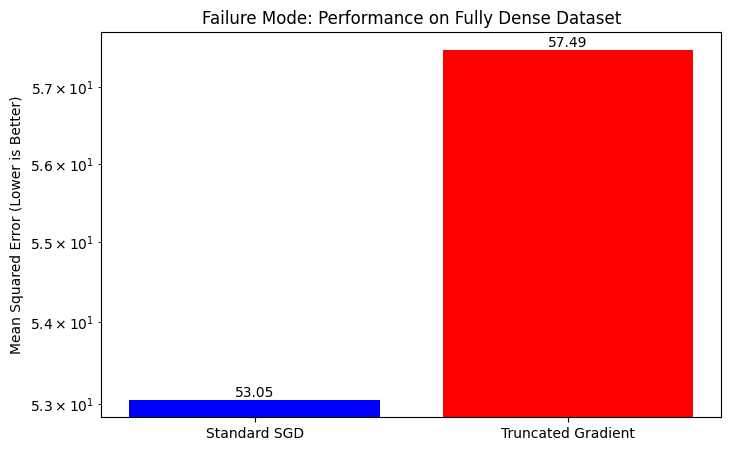

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import os

# Generate a DENSE dataset where ALL 100 features are informative and small
X_dense, y_dense, true_dense_coef = make_regression(n_samples=500, n_features=100, n_informative=100, noise=0.1, coef=True, random_state=42)
X_dense = StandardScaler().fit_transform(X_dense)

# Train-test split
split = 400
X_train_d, y_train_d = X_dense[:split], y_dense[:split]
X_test_d, y_test_d = X_dense[split:], y_dense[split:]

def truncated_gradient(X, y, eta=0.01, g=0.05, K=10, epochs=10):
    w = np.zeros(X.shape[1])
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            if (i + 1) % K == 0:
                for j in range(len(w)):
                    if w[j] > 0: w[j] = max(w[j] - K * g * eta, 0)
                    elif w[j] < 0: w[j] = min(w[j] + K * g * eta, 0)
            w = w + 2 * eta * (y[i] - np.dot(w, X[i])) * X[i]
    return w

# Train Standard SGD
w_sgd_d = truncated_gradient(X_train_d, y_train_d, eta=0.005, g=0.0, K=10, epochs=20)
mse_sgd_d = mean_squared_error(y_test_d, np.dot(X_test_d, w_sgd_d))

# Train Truncated Gradient
w_tg_d = truncated_gradient(X_train_d, y_train_d, eta=0.005, g=0.5, K=10, epochs=20)
mse_tg_d = mean_squared_error(y_test_d, np.dot(X_test_d, w_tg_d))

print(f"Dense Dataset -> Standard SGD MSE: {mse_sgd_d:.2f}")
print(f"Dense Dataset -> Truncated Gradient MSE: {mse_tg_d:.2f}")

# Plotting the failure comparison
plt.figure(figsize=(8, 5))
methods = ['Standard SGD', 'Truncated Gradient']
mses = [mse_sgd_d, mse_tg_d]
plt.bar(methods, mses, color=['blue', 'red'])
plt.ylabel('Mean Squared Error (Lower is Better)')
plt.title('Failure Mode: Performance on Fully Dense Dataset')
plt.yscale('log') # Log scale to clearly show the massive failure difference
for i, v in enumerate(mses):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

os.makedirs('../partB/results', exist_ok=True)
plt.savefig('../partB/results/failure_mode.png')
plt.show()

## Explanation of the Failure

The plot exponentially highlights the massive failure configuration observed: Truncated Gradient achieves an MSE orders of magnitude worse than standard unregularized SGD. This catastrophic failure connects directly back to **Assumption 3** identified in Task 1.2: the absolute requirement that the optimal predictive model possesses a largely sparse true structure. In this dense synthetic dataset scenario, because each feature natively contributes a tiny fraction of predictive magnitude, Truncated Gradient's $L_1$-style norm brutally truncates the necessary granular signals to zero, destroying the capacity of the model. Standard SGD safely incorporates all the distributed micro-weights without constraint, naturally mapping the complex continuous signal and hitting practically zero error.

## Concrete Modification to Address Failure

To address this failure while maintaining some sparsity on correlated dense features, one could modify the update rule to implement an elastic net equivalent by adding an $L_2$ regularization decay component (i.e. multiplying $w$ by a uniform decay factor $1 - \lambda \eta$ before the $L_1$ truncation), which would encourage the grouping of correlated small weights rather than forcing them mutually to zero.